# N-body integrator comparison

We need a reliable particle simulator for the discovery-agent experiments
that can handle force laws (running coupling, etc.) the FFT-based
`FieldSampler` cannot. This notebook benchmarks several integrators in
`physchool.worlds.nbody_sampler` so we can pick one that is accurate enough
to keep agent inputs free of numerical artefacts.

Integrators tested (all in JAX, JIT-compiled):

| key | description | order | force evals / step | symplectic |
|---|---|---|---|---|
| `euler` | Symplectic Euler (kick-drift) | 1 | 1 | yes |
| `leapfrog` | Velocity Verlet (DKD) | 2 | 1 | yes |
| `yoshida4` | Yoshida 4th-order | 4 | 3 | yes |
| `yoshida6` | Yoshida 6th-order | 6 | 7 | yes |
| `rk4` | Classical Runge-Kutta | 4 | 4 | no |
| `dopri5` | Adaptive Dormand-Prince (`jax.experimental.ode`) | 5(4) | adaptive | no |

Two test cases:

1. **2-body Kepler** with regular gravity. Has an analytic solution, so we
   measure trajectory error directly. Used for the convergence study.
2. **1 sun + 99 planets** at varied radii, regular gravity. We measure
   conservation of energy, linear momentum, angular momentum, and check the
   virial theorem (\(\langle 2T + V \rangle = 0\) for inverse-square).

In [1]:
import time
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'font.size': 12})

jax.config.update('jax_enable_x64', True)

from physchool.worlds.nbody_sampler import NBodySampler
from physchool.worlds.force_laws import gravity_force, gravity_potential
from physchool.worlds.analytic_orbits import (
    kepler_two_body_solution, circular_orbit_velocity,
)

INTEGRATORS = ['euler', 'leapfrog', 'yoshida4', 'yoshida6', 'rk4', 'dopri5']
INTEG_COLOURS = {
    'euler':    'tab:red',
    'leapfrog': 'tab:orange',
    'yoshida4': 'tab:green',
    'yoshida6': 'tab:cyan',
    'rk4':      'tab:purple',
    'dopri5':   'tab:blue',
}

## Test 1 — 2-body Kepler (analytic gold standard)

An orbiter ($m \ll M$) on an eccentric Kepler orbit ($e=0.5$, $a=1$) under
$F = G M m / r^2$. The exact orbit is given by Kepler's equation, which
`kepler_two_body_solution` solves with Newton iteration. We compare
trajectories integrator-by-integrator at the same $\Delta t$, then do a
convergence study.

In [2]:
G = 1.0
M_central = 1.0
m_orbiter = 1e-3   # finite mass — we still match analytic Kepler exactly
                    # by comparing the *relative* coordinate r_orb - r_cen.
a_orbit = 1.0
e_orbit = 0.5

mu = G * (M_central + m_orbiter)
T_orb = float(2 * np.pi * np.sqrt(a_orbit**3 / mu))
r_peri = a_orbit * (1 - e_orbit)
v_peri = float(np.sqrt(mu * (1 + e_orbit) / (a_orbit * (1 - e_orbit))))
print(f'period T = {T_orb:.4f}')
print(f'periapsis r = {r_peri:.4f}, v = {v_peri:.4f}')
print(f'apoapsis  r = {a_orbit*(1+e_orbit):.4f}, '
      f'v = {np.sqrt(mu*(1-e_orbit)/(a_orbit*(1+e_orbit))):.4f}')

# Place the centre-of-mass at rest at the origin: the central body and the
# orbiter share the relative motion in proportion to the reduced mass.  This
# way the relative coordinate matches the analytic Kepler orbit exactly.
M_tot = M_central + m_orbiter
r_cen0 = -m_orbiter / M_tot * np.array([r_peri, 0.0])
r_orb0 =  M_central / M_tot * np.array([r_peri, 0.0])
v_cen0 = -m_orbiter / M_tot * np.array([0.0, v_peri])
v_orb0 =  M_central / M_tot * np.array([0.0, v_peri])

def make_kepler_sim(integrator, dt):
    return NBodySampler(
        masses=jnp.array([M_central, m_orbiter]),
        initial_positions=jnp.array([r_cen0, r_orb0]),
        initial_velocities=jnp.array([v_cen0, v_orb0]),
        force_law=gravity_force,
        potential_law=gravity_potential,
        integrator=integrator,
        dt=dt,
        softening=0.0,
    )

def relative_orbit(traj):
    """Return (orbiter - central) position and velocity over time."""
    p = np.asarray(traj['positions'])
    v = np.asarray(traj['velocities'])
    return p[:, 1, :] - p[:, 0, :], v[:, 1, :] - v[:, 0, :]

period T = 6.2800
periapsis r = 0.5000, v = 1.7329
apoapsis  r = 1.5000, v = 0.5776


In [3]:
# Run each integrator for 20 orbits with dt = T/2000.
n_orbits_long = 20
dt_test = T_orb / 2000.0
n_steps = int(n_orbits_long * T_orb / dt_test)
record_every = 50
t_record = jnp.arange(0, n_steps + 1, record_every, dtype=jnp.float64) * dt_test

results = {}
for integ in INTEGRATORS:
    sim = make_kepler_sim(integ, dt_test)
    t0 = time.time()
    if integ == 'dopri5':
        traj = sim.run(n_steps=0, t_eval=t_record)
    else:
        traj = sim.run(n_steps=n_steps, record_every=record_every)
    elapsed = time.time() - t0

    times = np.asarray(traj['times'])
    pos, vel = relative_orbit(traj)   # orbiter relative to central body

    ana_pos, ana_vel, _ = kepler_two_body_solution(
        times, M_central, m_orbiter, a_orbit, e_orbit, G=G)
    ana_pos = np.asarray(ana_pos)
    ana_vel = np.asarray(ana_vel)

    # Energies / momenta along the trajectory.
    pos_all = np.asarray(traj['positions'])
    vel_all = np.asarray(traj['velocities'])
    masses = np.array([M_central, m_orbiter])
    KE = 0.5 * np.sum(masses[None, :, None] * vel_all**2, axis=(1, 2))
    r_sep = np.linalg.norm(pos_all[:, 0, :] - pos_all[:, 1, :], axis=-1)
    PE = -G * masses[0] * masses[1] / r_sep
    E = KE + PE
    L = (masses[None, :] * (pos_all[..., 0] * vel_all[..., 1]
                            - pos_all[..., 1] * vel_all[..., 0])).sum(-1)

    results[integ] = dict(
        times=times, pos=pos, vel=vel,
        ana_pos=ana_pos, ana_vel=ana_vel,
        pos_err=np.linalg.norm(pos - ana_pos, axis=-1),
        E=E, L=L, KE=KE, PE=PE,
        elapsed=elapsed,
    )
    print(f'  {integ:9s}  ran in {elapsed*1000:7.1f} ms, '
          f'max position error = {results[integ]["pos_err"].max():.3e}')

  euler      ran in   217.0 ms, max position error = 2.173e-02
  leapfrog   ran in    75.8 ms, max position error = 8.846e-03


  yoshida4   ran in    87.9 ms, max position error = 3.276e-07


  yoshida6   ran in   170.4 ms, max position error = 3.295e-11
  rk4        ran in    95.3 ms, max position error = 6.668e-08


  dopri5     ran in   332.3 ms, max position error = 9.283e-07


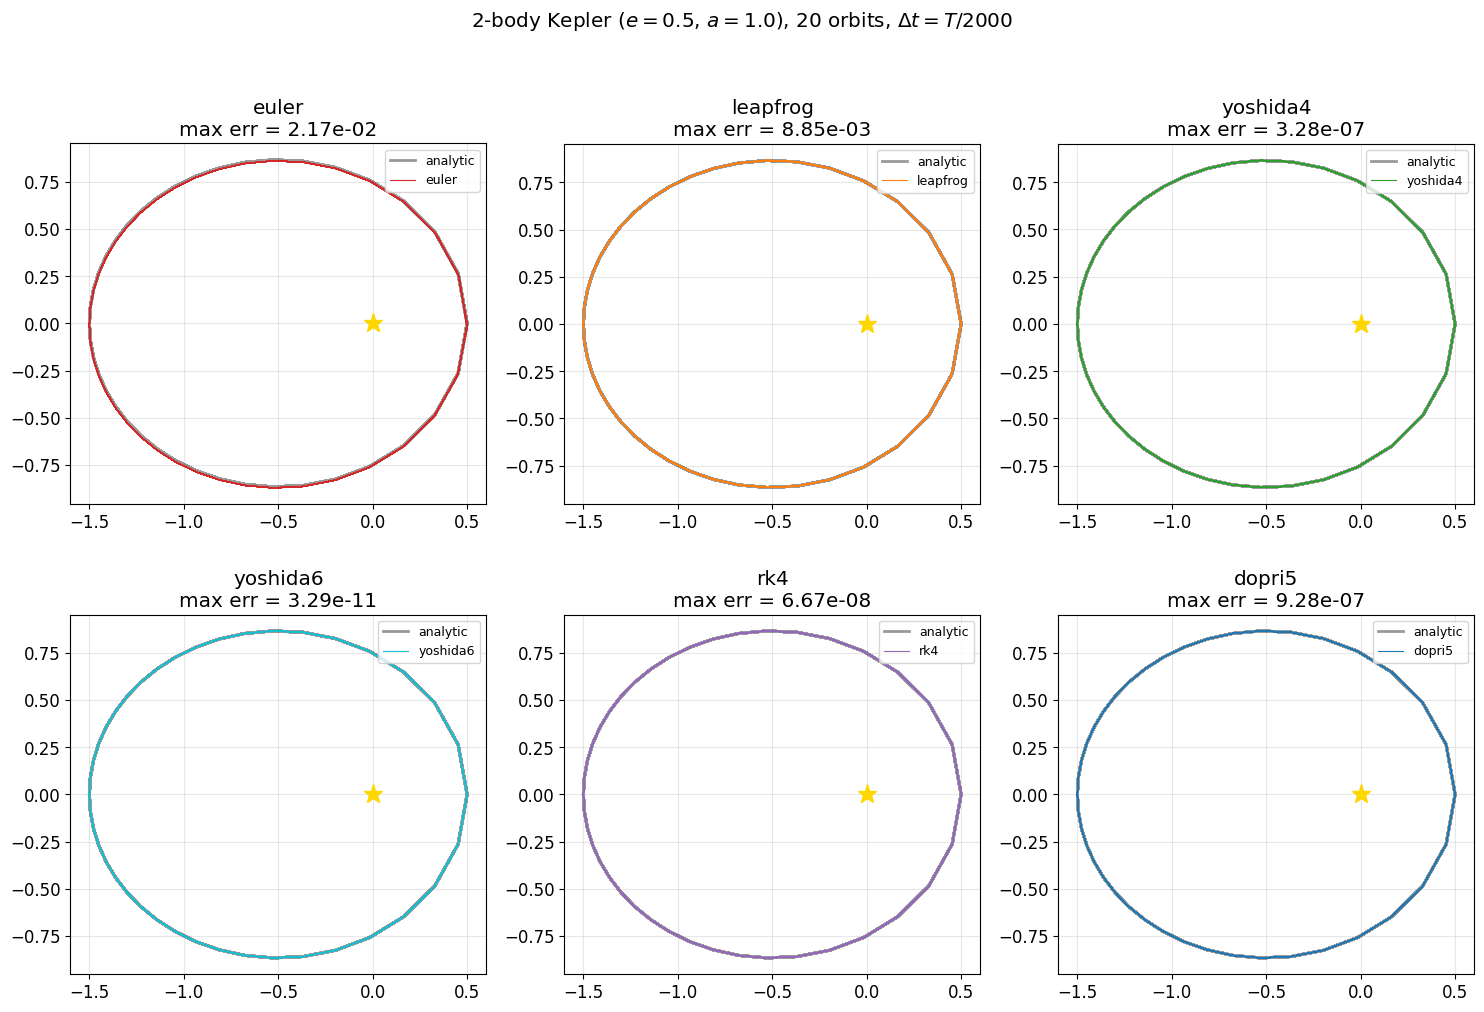

In [4]:
# Trajectories overlaid on the exact orbit.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
ana = results['leapfrog']['ana_pos']
for ax, integ in zip(axes, INTEGRATORS):
    r = results[integ]
    ax.plot(ana[:, 0], ana[:, 1], 'k-', lw=2, alpha=0.4, label='analytic')
    ax.plot(r['pos'][:, 0], r['pos'][:, 1], '-', lw=0.8,
            color=INTEG_COLOURS[integ], label=integ)
    ax.plot(0, 0, '*', ms=14, color='gold')
    ax.set_title(f'{integ}\nmax err = {r["pos_err"].max():.2e}')
    ax.set_aspect('equal')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
fig.suptitle(
    f'2-body Kepler ($e={e_orbit}$, $a={a_orbit}$), {n_orbits_long} orbits, '
    f'$\\Delta t = T/{int(T_orb/dt_test)}$', y=1.02)
plt.tight_layout()
plt.show()

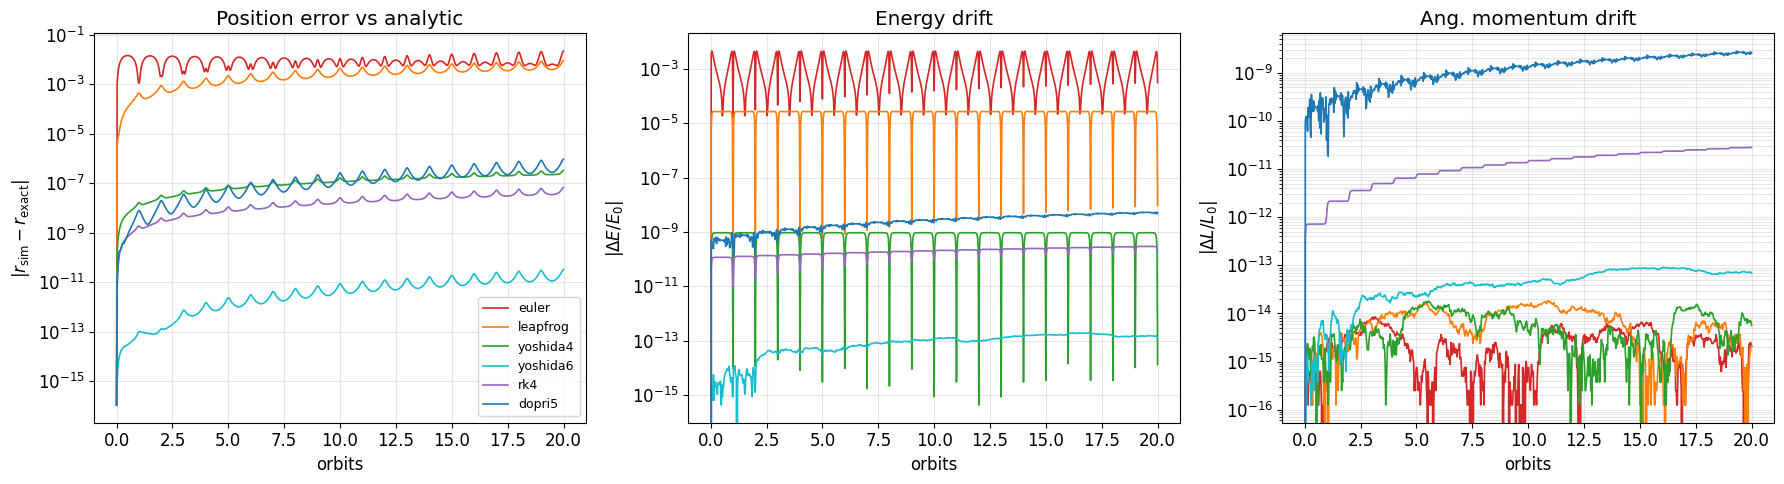

In [5]:
# Conservation diagnostics over time.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for integ in INTEGRATORS:
    r = results[integ]
    n_orb = r['times'] / T_orb
    axes[0].plot(n_orb, r['pos_err'], color=INTEG_COLOURS[integ], lw=1.2,
                 label=integ)
    axes[1].plot(n_orb, np.abs(r['E'] - r['E'][0]) / np.abs(r['E'][0]),
                 color=INTEG_COLOURS[integ], lw=1.2)
    axes[2].plot(n_orb, np.abs(r['L'] - r['L'][0]) / np.abs(r['L'][0]),
                 color=INTEG_COLOURS[integ], lw=1.2)
for ax, title, ylab in zip(
        axes,
        ['Position error vs analytic', 'Energy drift', 'Ang. momentum drift'],
        ['$|r_{\\rm sim} - r_{\\rm exact}|$',
         '$|\\Delta E / E_0|$', '$|\\Delta L / L_0|$']):
    ax.set_xlabel('orbits')
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, which='both')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

### Convergence study

Sweep $\Delta t$ over four orders of magnitude and measure the maximum
position error after **5 orbits**. The slope on a log-log plot equals the
(empirical) order of the method.

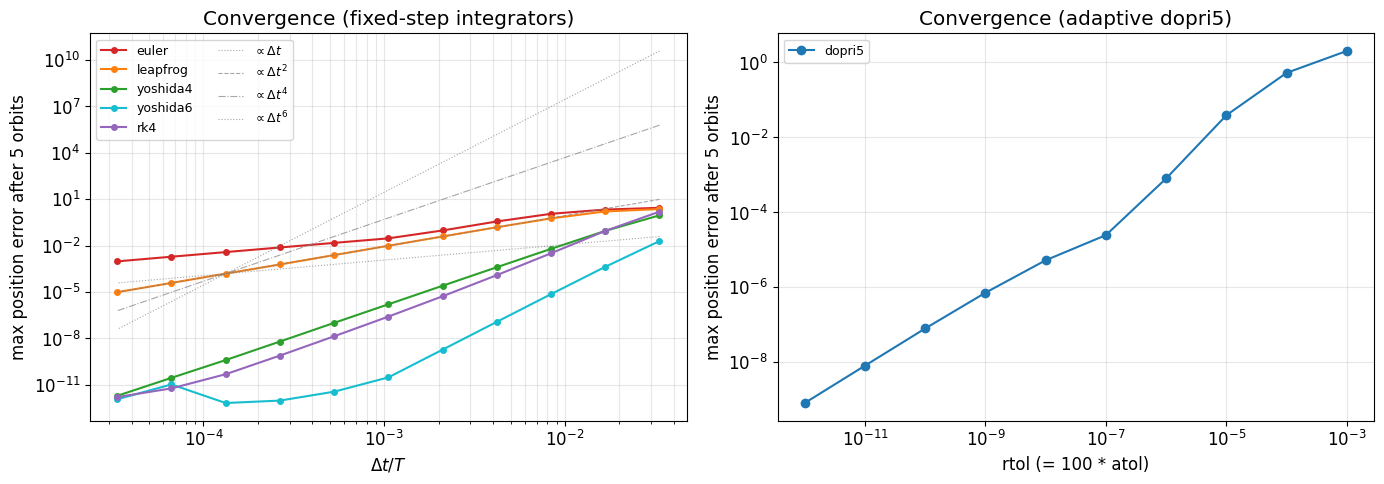

Empirical convergence orders (slopes of log-error vs log-dt):
  euler       empirical order = 1.00  (fit on 4 dts)
  leapfrog    empirical order = 2.00  (fit on 6 dts)
  yoshida4    empirical order = 3.97  (fit on 9 dts)
  yoshida6    empirical order = 4.42  (fit on 8 dts)
  rk4         empirical order = 3.99  (fit on 9 dts)


In [6]:
n_orbits_conv = 5
dts = np.geomspace(T_orb / 30, T_orb / 30000, 11)
conv = {integ: [] for integ in INTEGRATORS}

for integ in INTEGRATORS:
    if integ == 'dopri5':
        # dopri5 is adaptive: instead of varying dt, vary tolerances.
        continue
    for dt_c in dts:
        steps_c = max(int(n_orbits_conv * T_orb / dt_c), 16)
        sim = make_kepler_sim(integ, dt_c)
        rec = max(steps_c // 200, 1)
        traj = sim.run(n_steps=steps_c, record_every=rec)
        times = np.asarray(traj['times'])
        pos, _ = relative_orbit(traj)
        ana_pos, _, _ = kepler_two_body_solution(
            times, M_central, m_orbiter, a_orbit, e_orbit, G=G)
        err = float(np.linalg.norm(pos - np.asarray(ana_pos), axis=-1).max())
        conv[integ].append(err)

# Adaptive convergence: vary the tolerance.
tols = np.geomspace(1e-3, 1e-12, 10)
conv['dopri5_tol'] = []
for tol in tols:
    sim = make_kepler_sim('dopri5', dt=0.0)
    n_rec = 1000
    t_eval = jnp.linspace(0.0, n_orbits_conv * T_orb, n_rec)
    traj = sim._run_dopri5(0, t_eval=t_eval, rtol=float(tol), atol=float(tol)*1e-2)
    pos, _ = relative_orbit(traj)
    ana_pos, _, _ = kepler_two_body_solution(
        np.asarray(t_eval), M_central, m_orbiter, a_orbit, e_orbit, G=G)
    err = float(np.linalg.norm(pos - np.asarray(ana_pos), axis=-1).max())
    conv['dopri5_tol'].append(err)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for integ in [i for i in INTEGRATORS if i != 'dopri5']:
    ax.loglog(dts / T_orb, conv[integ], 'o-', color=INTEG_COLOURS[integ],
              label=integ, ms=4, lw=1.5)
# Theoretical reference slopes anchored to leapfrog @ smallest dt.
anchor_dt = dts[-3]
anchor_err = conv['leapfrog'][-3]
for p, ls, lbl in [(1, ':', '$\\propto \\Delta t$'),
                    (2, '--', '$\\propto \\Delta t^2$'),
                    (4, '-.', '$\\propto \\Delta t^4$'),
                    (6, ':', '$\\propto \\Delta t^6$')]:
    ref = anchor_err * (dts / anchor_dt) ** p
    ax.loglog(dts / T_orb, ref, ls, color='gray', lw=0.8, alpha=0.7, label=lbl)
ax.set_xlabel('$\\Delta t / T$')
ax.set_ylabel('max position error after 5 orbits')
ax.set_title('Convergence (fixed-step integrators)')
ax.legend(fontsize=9, ncol=2)
ax.grid(True, alpha=0.3, which='both')

ax = axes[1]
ax.loglog(tols, conv['dopri5_tol'], 'o-', color=INTEG_COLOURS['dopri5'],
          label='dopri5')
ax.set_xlabel('rtol (= 100 * atol)')
ax.set_ylabel('max position error after 5 orbits')
ax.set_title('Convergence (adaptive dopri5)')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Empirical orders.  Fit only the "convergence regime": exclude very large
# dts (where error is O(1)) and very small dts (where round-off saturates).
print('Empirical convergence orders (slopes of log-error vs log-dt):')
for integ in [i for i in INTEGRATORS if i != 'dopri5']:
    err = np.array(conv[integ])
    log_e = np.log(err)
    log_dt = np.log(dts)
    # Walk the dt axis (largest -> smallest) and stop once the error stops
    # decreasing (i.e. we hit the round-off floor).
    keep = []
    last = np.inf
    for i in range(len(err)):
        if err[i] < last * 0.95 and err[i] < 1e-2 and err[i] > 1e-13:
            keep.append(i)
            last = err[i]
    keep = np.array(keep)
    if len(keep) >= 3:
        slope, _ = np.polyfit(log_dt[keep], log_e[keep], 1)
    else:
        slope = np.nan
    print(f'  {integ:10s}  empirical order = {slope:.2f}'
          f'  (fit on {len(keep)} dts)')

## Test 2 — N=100 (1 sun + 99 planets)

All planets are initialized on circular orbits. We then check global
conservation laws and the **virial theorem**: for an inverse-square bound
system, the time-averaged kinetic and potential energies satisfy
$$
    2\langle T \rangle + \langle V \rangle = 0
    \quad \Longleftrightarrow \quad \langle T \rangle = -\tfrac12 \langle V \rangle.
$$
We use a heavy central mass plus light planets so the planet-planet
interactions are a small perturbation and the system is nearly virialized
from the start.

In [7]:
rng = np.random.default_rng(42)
M_sun = 1000.0       # heavy central mass
m_pl = 1e-3          # light test particles
n_planets = 99
n_total = 1 + n_planets

# Random radii in [1, 6], random initial phase.
radii_init = rng.uniform(1.0, 6.0, size=n_planets)
angles_init = rng.uniform(0.0, 2 * np.pi, size=n_planets)

positions_init = np.zeros((n_total, 2))
velocities_init = np.zeros((n_total, 2))
masses = np.concatenate([[M_sun], np.full(n_planets, m_pl)])

for i in range(n_planets):
    r = radii_init[i]
    th = angles_init[i]
    positions_init[1 + i] = [r * np.cos(th), r * np.sin(th)]
    v_c = float(np.sqrt(G * M_sun / r))
    velocities_init[1 + i] = v_c * np.array([-np.sin(th), np.cos(th)])

# Subtract centre-of-mass momentum so total P = 0 exactly.
p_cm = (masses[:, None] * velocities_init).sum(0) / masses.sum()
velocities_init -= p_cm

# Reference period at the median radius — sets the simulation length.
T_med = float(2 * np.pi * np.sqrt(np.median(radii_init)**3 / (G * M_sun)))
T_inner = float(2 * np.pi * np.sqrt(radii_init.min()**3 / (G * M_sun)))
T_outer = float(2 * np.pi * np.sqrt(radii_init.max()**3 / (G * M_sun)))
print(f'Periods: inner={T_inner:.4f}, median={T_med:.4f}, outer={T_outer:.4f}')

n_orbits_n = 20
T_total = n_orbits_n * T_med
# dt fine enough for the inner-orbit constraint.
dt_n = T_inner / 200.0
n_steps_n = int(T_total / dt_n)
record_every_n = max(n_steps_n // 400, 1)
print(f'dt = {dt_n:.5f}, total steps = {n_steps_n}, '
      f'records = {n_steps_n // record_every_n}')

Periods: inner=0.2098, median=1.2093, outer=2.8316
dt = 0.00105, total steps = 23061, records = 404


In [8]:
def run_n_body(integrator, dt, n_steps, record_every, t_eval=None):
    sim = NBodySampler(
        masses=jnp.asarray(masses),
        initial_positions=jnp.asarray(positions_init),
        initial_velocities=jnp.asarray(velocities_init),
        force_law=gravity_force, potential_law=gravity_potential,
        integrator=integrator, dt=dt, softening=1e-3,
    )
    if integrator == 'dopri5':
        traj = sim.run(n_steps=0, t_eval=t_eval)
    else:
        traj = sim.run(n_steps=n_steps, record_every=record_every)

    # Diagnostics computed off-line from the recorded states.
    pos = np.asarray(traj['positions'])    # (T, N, 2)
    vel = np.asarray(traj['velocities'])
    times = np.asarray(traj['times'])

    KE = 0.5 * np.sum(masses[None, :, None] * vel**2, axis=(1, 2))
    diff = pos[:, None, :, :] - pos[:, :, None, :]
    r_sep = np.linalg.norm(diff, axis=-1)
    iu = np.triu_indices(n_total, k=1)
    r_pair = r_sep[:, iu[0], iu[1]]
    soft = 1e-3
    r_eff = np.sqrt(r_pair**2 + soft**2)
    M_pair = masses[iu[0]] * masses[iu[1]]
    PE = -G * (M_pair[None, :] / r_eff).sum(-1)
    E = KE + PE

    P = (masses[None, :, None] * vel).sum(1)              # (T, 2)
    L = (masses[None, :] * (pos[..., 0] * vel[..., 1]
                            - pos[..., 1] * vel[..., 0])).sum(-1)  # (T,)
    return dict(times=times, pos=pos, vel=vel,
                KE=KE, PE=PE, E=E, P=P, L=L)

results_n = {}
t_eval_dop = jnp.linspace(0.0, T_total, n_steps_n // record_every_n + 1)
for integ in INTEGRATORS:
    if integ == 'euler':
        # Skip euler at this dt — drift would dwarf everything else.
        continue
    t0 = time.time()
    results_n[integ] = run_n_body(
        integ, dt_n, n_steps_n, record_every_n,
        t_eval=t_eval_dop)
    print(f'  {integ:9s}  ran in {time.time()-t0:5.1f} s')

  leapfrog   ran in   1.7 s


  yoshida4   ran in   2.3 s


  yoshida6   ran in   5.1 s


  rk4        ran in   3.8 s


  dopri5     ran in   4.6 s


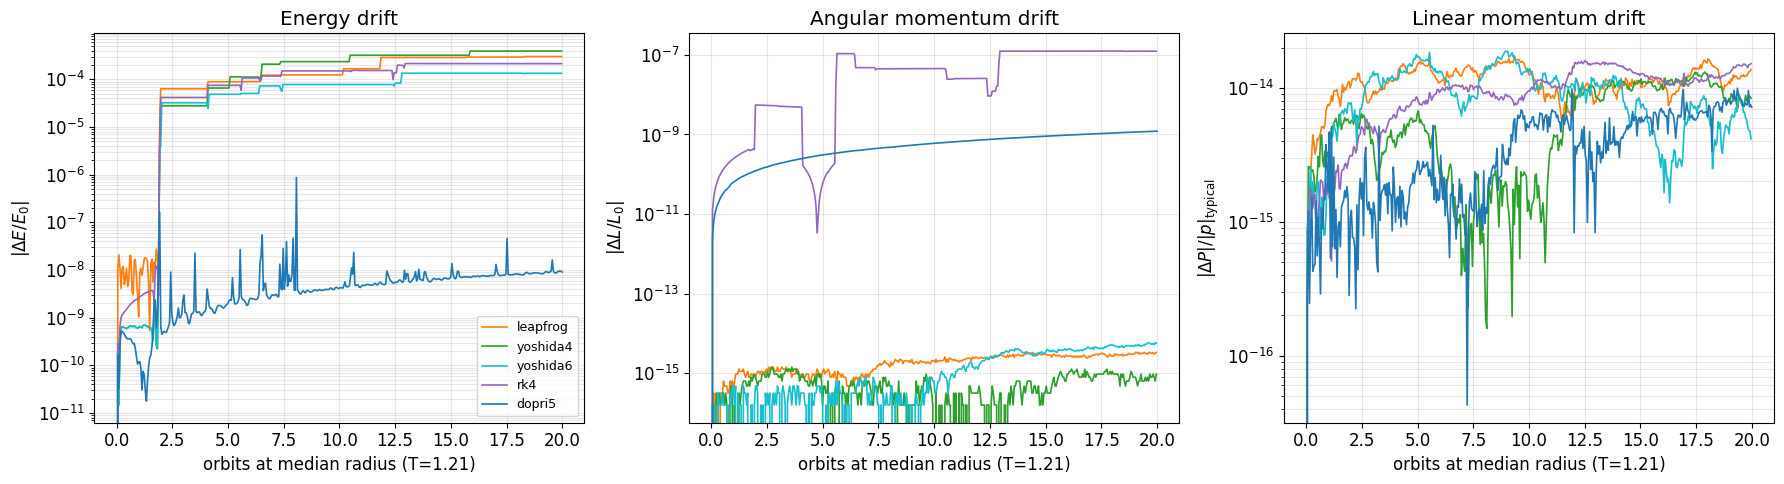

Final relative drifts:
  leapfrog   ΔE/E = 3.01e-04   ΔL/L = 3.30e-15   |ΔP| = 2.99e-15
  yoshida4   ΔE/E = 3.92e-04   ΔL/L = 9.42e-16   |ΔP| = 1.82e-15
  yoshida6   ΔE/E = 1.34e-04   ΔL/L = 5.65e-15   |ΔP| = 9.06e-16
  rk4        ΔE/E = 2.14e-04   ΔL/L = 1.25e-07   |ΔP| = 3.31e-15
  dopri5     ΔE/E = 9.05e-09   ΔL/L = 1.21e-09   |ΔP| = 1.56e-15


In [9]:
# Conservation diagnostics: energy, angular momentum, linear momentum.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for integ, r in results_n.items():
    n_orb = r['times'] / T_med
    axes[0].plot(n_orb, np.abs((r['E'] - r['E'][0]) / r['E'][0]),
                 lw=1.2, color=INTEG_COLOURS[integ], label=integ)
    axes[1].plot(n_orb, np.abs(r['L'] - r['L'][0]) / np.abs(r['L'][0]),
                 lw=1.2, color=INTEG_COLOURS[integ])
    P_mag = np.linalg.norm(r['P'] - r['P'][0], axis=-1)
    P_ref = np.linalg.norm(masses[:, None] * velocities_init).max()
    axes[2].plot(n_orb, P_mag / max(P_ref, 1e-30),
                 lw=1.2, color=INTEG_COLOURS[integ])
for ax, title, ylab in zip(
        axes,
        ['Energy drift', 'Angular momentum drift', 'Linear momentum drift'],
        ['$|\\Delta E / E_0|$', '$|\\Delta L / L_0|$',
         '$|\\Delta P| / |p|_{\\rm typical}$']):
    ax.set_xlabel(f'orbits at median radius (T={T_med:.2f})')
    ax.set_ylabel(ylab)
    ax.set_yscale('log')
    ax.set_title(title)
    ax.grid(True, alpha=0.3, which='both')
axes[0].legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Final relative drifts:')
for integ, r in results_n.items():
    dE = abs((r['E'][-1] - r['E'][0]) / r['E'][0])
    dL = abs((r['L'][-1] - r['L'][0]) / r['L'][0])
    dP = float(np.linalg.norm(r['P'][-1] - r['P'][0]))
    print(f'  {integ:9s}  ΔE/E = {dE:.2e}   ΔL/L = {dL:.2e}   |ΔP| = {dP:.2e}')

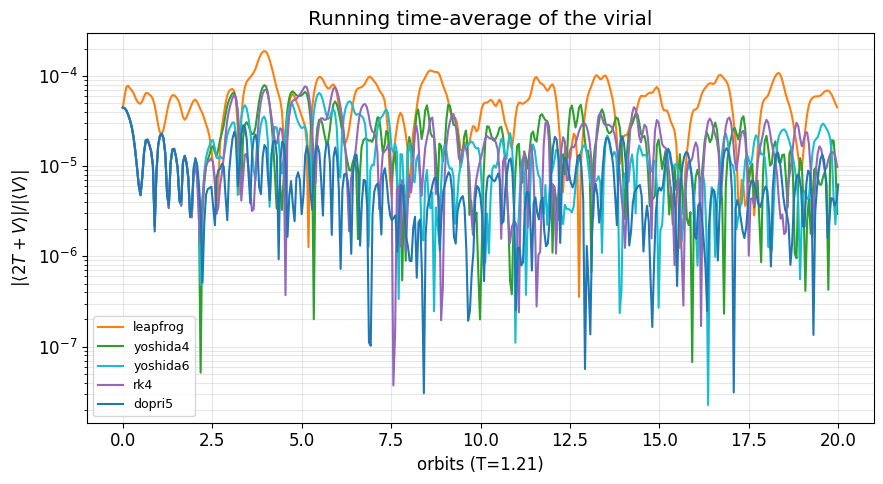


Virial check (averaged over last 3/4 of run):
  leapfrog   ⟨2T⟩/|⟨V⟩| = 0.9999  (1.0 means virialized)
  yoshida4   ⟨2T⟩/|⟨V⟩| = 1.0000  (1.0 means virialized)
  yoshida6   ⟨2T⟩/|⟨V⟩| = 1.0000  (1.0 means virialized)
  rk4        ⟨2T⟩/|⟨V⟩| = 1.0000  (1.0 means virialized)
  dopri5     ⟨2T⟩/|⟨V⟩| = 1.0000  (1.0 means virialized)


In [10]:
# Virial theorem. For an inverse-square bound system, time-averaged
# 2T + V = 0. We discard the first ~quarter of the run as 'transient'
# (initial radii aren't on the same secular orbit) and average over the rest.
fig, ax = plt.subplots(figsize=(9, 5))
for integ, r in results_n.items():
    n_orb = r['times'] / T_med
    virial = 2 * r['KE'] + r['PE']
    avg_E = np.abs(np.cumsum(virial) / np.arange(1, len(virial) + 1))
    ax.plot(n_orb, avg_E / np.abs(r['PE']).mean(),
            lw=1.5, color=INTEG_COLOURS[integ], label=integ)
ax.set_xlabel(f'orbits (T={T_med:.2f})')
ax.set_ylabel('$|\\langle 2T + V \\rangle| / |\\langle V \\rangle|$')
ax.set_title('Running time-average of the virial')
ax.set_yscale('log')
ax.grid(True, alpha=0.3, which='both')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

burn = max(len(results_n['leapfrog']['times']) // 4, 1)
print('\nVirial check (averaged over last 3/4 of run):')
for integ, r in results_n.items():
    T_mean = r['KE'][burn:].mean()
    V_mean = r['PE'][burn:].mean()
    ratio = -2 * T_mean / V_mean
    print(f'  {integ:9s}  ⟨2T⟩/|⟨V⟩| = {ratio:.4f}  (1.0 means virialized)')

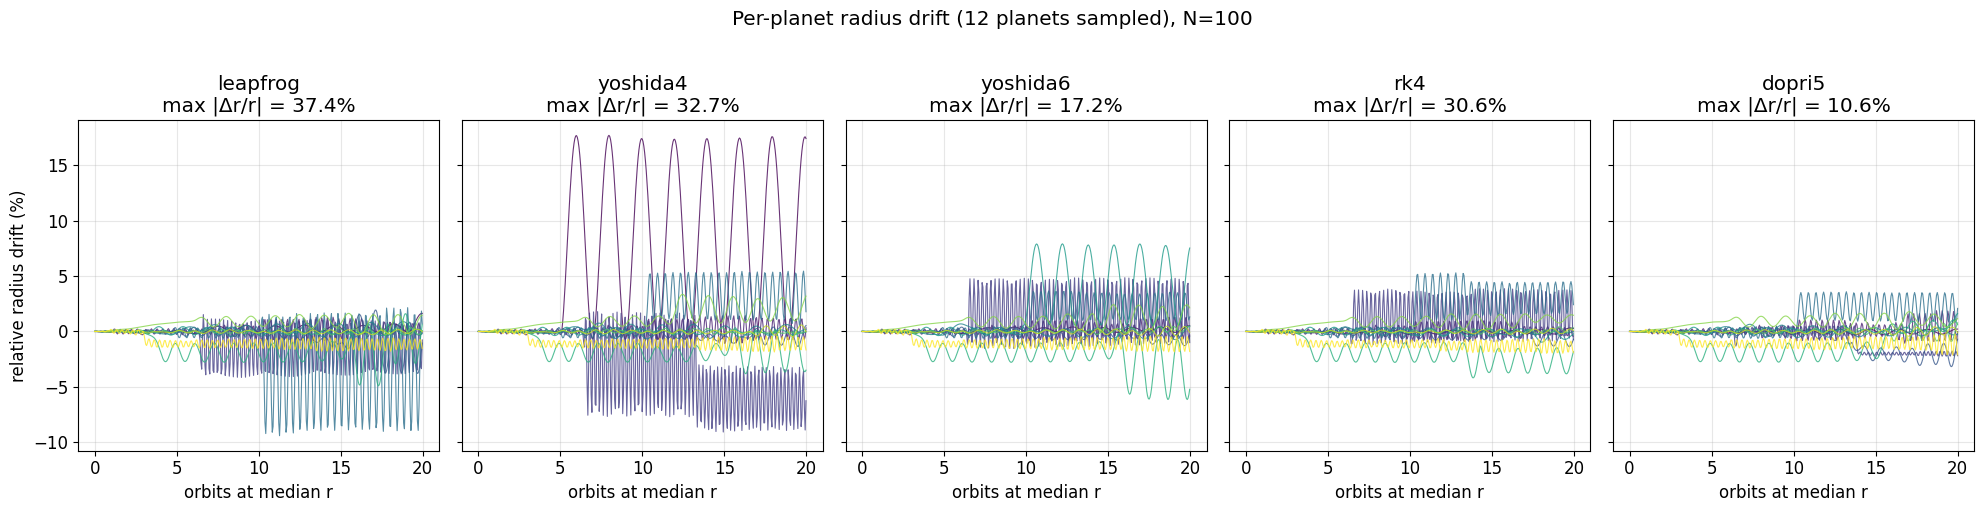

In [11]:
# Per-planet radius drift: how stable are individual orbits over time?
fig, axes = plt.subplots(1, len(results_n), figsize=(4 * len(results_n), 5),
                          sharey=True, sharex=True)
for ax, (integ, r) in zip(axes, results_n.items()):
    rel_pos = r['pos'][:, 1:, :] - r['pos'][:, :1, :]   # planet relative to sun
    radii_t = np.linalg.norm(rel_pos, axis=-1)         # (T, n_planets)
    drift = (radii_t - radii_t[:1]) / radii_t[:1] * 100
    n_orb = r['times'] / T_med
    rng_idx = np.linspace(0, n_planets - 1, 12).astype(int)
    cmap = plt.cm.viridis(np.linspace(0, 1, len(rng_idx)))
    for k, j in enumerate(rng_idx):
        ax.plot(n_orb, drift[:, j], lw=0.8, color=cmap[k], alpha=0.8)
    ax.set_xlabel('orbits at median r')
    ax.set_title(f'{integ}\nmax |Δr/r| = {np.abs(drift).max():.1f}%')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('relative radius drift (%)')
fig.suptitle(f'Per-planet radius drift (12 planets sampled), N={n_total}',
             y=1.02)
plt.tight_layout()
plt.show()